In [4]:
# imports

import pandas as pd
import numpy as np
import nltk
import re
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

In [5]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /home/anson/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /home/anson/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/anson/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [9]:
# Preprocess Raw Text

with open("Complete_data.txt", "r", encoding='ISO-8859-1') as f:
    raw_text = f.read()


In [10]:
# Lowercase, remove non-alphabet
text = raw_text.lower()
text = re.sub(r'[^a-z\s]', '', text)


In [11]:
# tokenization
tokens = nltk.word_tokenize(text)
tokens = [t for t in tokens if t not in stopwords.words('english')]


In [12]:
# stemming and lemmatization

stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

stemmed = [stemmer.stem(t) for t in tokens]
lemmatized = [lemmatizer.lemmatize(t) for t in tokens]

/tmp/ipykernel_8549/1986814123.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(freqs), y=list(words), palette="viridis")


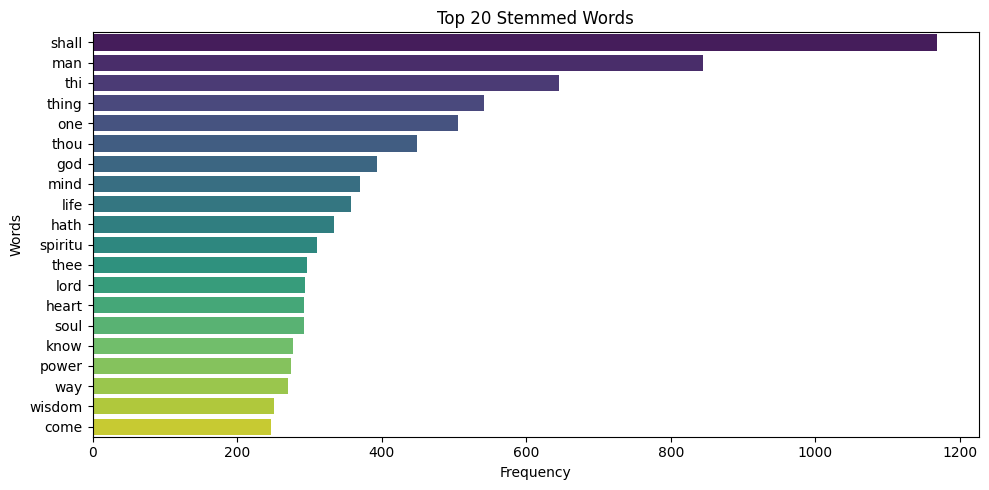

/tmp/ipykernel_8549/1986814123.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(freqs), y=list(words), palette="viridis")


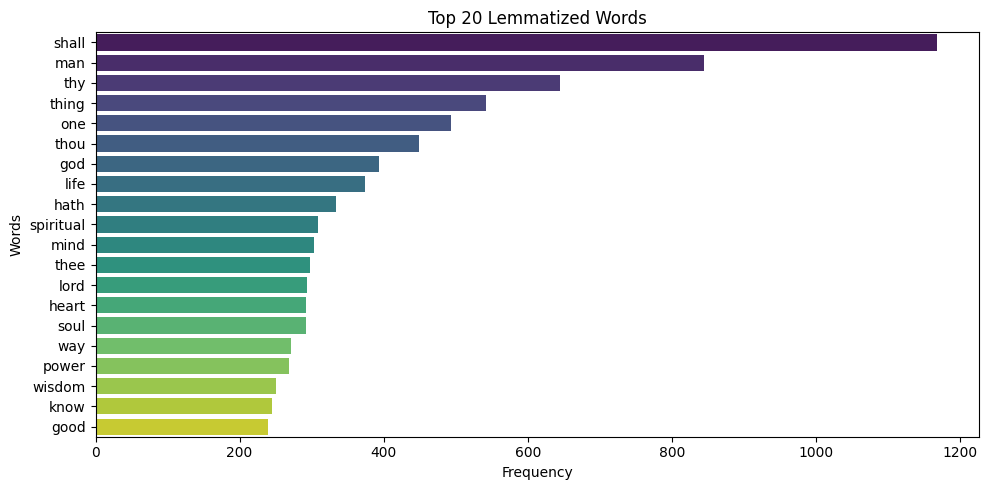

In [15]:
# visualisation
def plot_top_words(word_list, title, n=20):
    freq = nltk.FreqDist(word_list)
    common = freq.most_common(n)
    words, freqs = zip(*common)
    plt.figure(figsize=(10, 5))
    sns.barplot(x=list(freqs), y=list(words), palette="viridis")
    plt.title(title)
    plt.xlabel("Frequency")
    plt.ylabel("Words")
    plt.tight_layout()
    plt.show()
    
# from collections import Counter
# def show_wordcloud_freq(word_list, title):
#     word_freq = dict(Counter(word_list))
#     wc = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_freq)
#     plt.figure(figsize=(10, 5))
#     plt.imshow(wc, interpolation="bilinear")
#     plt.axis("off")
#     plt.title(title)
#     plt.tight_layout()
#     plt.show()

# Visualizations
plot_top_words(stemmed, "Top 20 Stemmed Words")
plot_top_words(lemmatized, "Top 20 Lemmatized Words")
# show_wordcloud(stemmed, "Word Cloud - Stemmed")
# show_wordcloud(lemmatized, "Word Cloud - Lemmatized")

In [16]:
# feature extraction

text_data = [" ".join(lemmatized)]

# Bag of Words
bow_vec = CountVectorizer()
X_bow = bow_vec.fit_transform(text_data)
print("BoW Shape:", X_bow.shape)

# Bigrams
bi_vec = CountVectorizer(ngram_range=(2, 2))
X_bi = bi_vec.fit_transform(text_data)
print("Bigrams Shape:", X_bi.shape)

# TF-IDF
tfidf_vec = TfidfVectorizer()
X_tfidf = tfidf_vec.fit_transform(text_data)
print("TF-IDF Shape:", X_tfidf.shape)

BoW Shape: (1, 7581)
Bigrams Shape: (1, 47706)
TF-IDF Shape: (1, 7581)
